# <span style='color:#009999'> <span style='font-family:serif'> <font size="15"> **LLC4320 data access demonstration using `xarray` and sample selection with the Poseidon-viewer *save* (store) function**
 
<font size="3"> This notebook demonstrates access to LLC4320 data with cutout, section, and station selection from the Poseidon-viewer using the *save* protocol. It is available on Johns Hopkins University's SciServer/Kraken domain. 
This method requires that the Poseidon Viewer is running in this SciServer container.

<font size="3"> To see the Poseidon-viewer *copy and paste* protocol with LLC4320 data, see the [`Poseidon_viewer_copy_paste_LLC4320_demonstration.ipynb`]() notebook.
    
<font size="3"> For quick access to the LLC4320 data, see the [`LLC4320_access_demonstration.ipynb`]() notebook.

Miguel A. Jimenez-Urias May '25, Thomas Haine, GPT5.4 Jul '26


<span style='color:#0066cc'><font size="5">**1. Select the *stations*, *section* or *polygon* you want in the Poseidon Viewer, then save the data, and then run this notebook to plot**

1. Use the Poseidon Viewer app to select what you want to plot using the station, section, or cutout button:

<span style='color:#0066cc'><font size="4">**Station selection:**

<div>
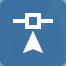
</div>

To select multiple stations use the shift key.

<span style='color:#0066cc'><font size="4">**Section selection:**

<div>
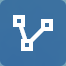
</div>

<span style='color:#0066cc'><font size="4">**Cutout selection:**

<div>
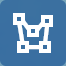
</div>
    

<span style='color:#0066cc'><font size="5">**2. Select then save (store) the data in the Poseidon Viewer via the *save* button:**

<div>
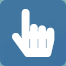
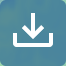
</div>
    
The data from your selection can now be automatically imported into this Jupyter notebook using the `get_shapes()` function.

<span style='color:#0066cc'><font size="5"> **Setup**

In [1]:
import fsspec
import xarray as xr
import dask
from dask import delayed, compute
from dask.distributed import Client
import matplotlib.pyplot as plt
from matplotlib.path import Path
from shapely.geometry import shape
import gc
import numpy as np
from scipy.spatial import cKDTree
import pandas as pd
import json
from poseidon_viewer import get_shapes

client = Client(n_workers=4, threads_per_worker=2)  # Basic limited cpu example

<span style='color:#0066cc'><font size="5"> **Define all the LLC4320 data variables**

In [2]:
ceph_path = "/home/idies/workspace/poseidon_ceph/LLC4320/"
Ker_path = ceph_path + "Kerchunks/"

# Individual 4D variables:
Salt_json= Ker_path + "LLC4320_SALT.json"
Theta_json = Ker_path + "LLC4320_THETA.json"
U_json =  Ker_path + "LLC4320_U.json"
V_json =  Ker_path+ "LLC4320_V.json"
W_json =   Ker_path + "LLC4320_W.json"

# Individual 3D (surface) variables:
Eta_json = Ker_path + "LLC4320_Eta.json"
KPPhbl_json = Ker_path + "LLC4320_KPPhbl.json"
PhiBot_json =  Ker_path + "LLC4320_PhiBot.json"
SIarea_json =  Ker_path + "LLC4320_SIarea.json"
SIheff_json =  Ker_path + "LLC4320_SIheff.json"
SIhsalt_json =  Ker_path + "LLC4320_SIhsalt.json"
SIhsnow_json =  Ker_path + "LLC4320_SIhsnow.json"
SIuice_json =  Ker_path + "LLC4320_SIuice.json"
SIvice_json =  Ker_path + "LLC4320_SIvice.json"
oceFWflx_json =  Ker_path + "LLC4320_oceFWflx.json"
oceQnet_json =  Ker_path + "LLC4320_oceQnet.json"
oceQsw_json =  Ker_path + "LLC4320_oceQsw.json"
oceSflux_json =  Ker_path + "LLC4320_oceSflux.json"
oceTAUX_json =  Ker_path + "LLC4320_oceTAUX.json"
oceTAUY_json =  Ker_path + "LLC4320_oceTAUY.json"

<span style='color:#0066cc'><font size="5"> **Open the zarr stores**


### Identify all variables you need in your dataset by including the json path of its Kerchunk references 

```python
json_paths=[Kerchunk_json1, Kerchunk_json2,...]
```

<font size="3"> You select only the variables of interest as follows:

In [3]:
# Here, add the json files of the variables you want to include in your dataset
json_paths = [Salt_json, Theta_json, U_json, V_json, W_json, Eta_json, KPPhbl_json, 
              PhiBot_json,  SIarea_json, SIheff_json, SIhsalt_json, SIhsnow_json, 
              SIuice_json, SIvice_json, oceFWflx_json, oceQnet_json, oceQsw_json,
              oceSflux_json, oceTAUX_json, oceTAUY_json,
             ]
json_paths = [Salt_json, Theta_json]


<span style='color:#0066cc'><font size="5"> **LLC4320 grid and masks**


In [4]:
grid_path = ceph_path
ds_grid = xr.open_zarr(grid_path)
ds_grid = ds_grid.set_coords([var for var in ds_grid.data_vars])

<span style='color:#0066cc'><font size="5"> **Create xarray datasets for each individual variable**

<font size="3"> The xarray dataset creation may take $\sim 10\times N $ seconds, with $N$ the number of variables selected (json files).  
    
<font size="3"> **NOTE**: There is no significant performance gain when using `dask` for parallel read/creation of the mapper object. The code runs sequentially (unfortunately). But using `dask` provides a clean way to create the xarray dataset in a few lines, avoiding repeated code.

In [5]:
def open_mapper(json_file):
    fs = fsspec.filesystem("reference", fo=json_file)
    mapper = fs.get_mapper("")
    return mapper

# Distribute JSON paths to workers first
scattered_paths = client.scatter(json_paths, broadcast=False)
# Then submit open_mapper to each
futures = [client.submit(open_mapper, path) for path in scattered_paths]

# Optionally wait for all to complete
mappers = client.gather(futures)  # This doesn't move data, just ensures completion

<span style='color:#0066cc'><font size="5"> **Concatenate into a single xarray dataset then cleanup**

In [6]:
ds = xr.merge([xr.open_zarr(mapper, consolidated=False) for mapper in mappers]+[ds_grid])
_ = client.run(gc.collect)  # also on workers
client.close()

<span style='color:#0066cc'><font size="5"> **Next, read incoming Poseidon-viewer data automatically using `get_shapes()` and dispatch processing and plotting appropriately**
    
This cell defines the dispatch, processing, and plotting functions. 

In [10]:
# -------------------------------------------------------------------
# 1) Load GeoJSON from your function
# -------------------------------------------------------------------
geojson = json.loads(get_shapes())

# -------------------------------------------------------------------
# 2) Helper: normalize to a list of features
# -------------------------------------------------------------------
def get_feature_list(geojson_obj):
    """
    Accepts either a FeatureCollection or a single Feature.
    Returns a list of feature dicts.
    """
    if geojson_obj.get("type") == "FeatureCollection":
        return geojson_obj["features"]
    elif geojson_obj.get("type") == "Feature":
        return [geojson_obj]
    else:
        raise ValueError(f"Unsupported GeoJSON type: {geojson_obj.get('type')}")

# -------------------------------------------------------------------
# 3) Dispatcher functions
#    Replace these calls with your already-working analysis code
# -------------------------------------------------------------------
def process_point_features(features, ds):
    """
    Point -> station profiles vs depth
    """

    print(f"Running point/station analysis for {len(features)} feature(s)")
    # ------------------------------------------------------------
    # Parse station points and time window
    # ------------------------------------------------------------
    features = geojson["features"]

    t0 = pd.to_datetime(features[0]["properties"]["timeFrom"])
    t1 = pd.to_datetime(features[0]["properties"]["timeTo"])

    # ------------------------------------------------------------
    # Choose fields
    # ------------------------------------------------------------
    theta = ds["Theta"].isel(time=0)   # (k, face, j, i)
    salt  = ds["Salt"].isel(time=0)    # (k, face, j, i)

    XC = ds["XC"]   # lon
    YC = ds["YC"]   # lat
    depth = -ds["Z"].values   # positive down

    # ------------------------------------------------------------
    # Build KDTree only from horizontal grid centers
    # Store mapping from tree point -> (face, j, i)
    # ------------------------------------------------------------
    grid_pts = []
    grid_meta = []

    for f in range(XC.sizes["face"]):
        # Load only horizontal coordinates for this face
        XC_f = XC.isel(face=f).compute()
        YC_f = YC.isel(face=f).compute()

        x = XC_f.values.ravel()
        y = YC_f.values.ravel()

        good = np.isfinite(x) & np.isfinite(y)
        if not np.any(good):
            continue

        # horizontal points
        grid_pts.append(np.column_stack([x[good], y[good]]))

        # corresponding (face, j, i)
        jj, ii = np.indices(XC_f.shape)
        meta = np.column_stack([
            np.full(np.count_nonzero(good), f, dtype=np.int32),
            jj.ravel()[good].astype(np.int32),
            ii.ravel()[good].astype(np.int32),
        ])
        grid_meta.append(meta)

    grid_pts = np.vstack(grid_pts)
    grid_meta = np.vstack(grid_meta)

    tree = cKDTree(grid_pts)

    # ------------------------------------------------------------
    # Query stations
    # ------------------------------------------------------------
    station_profiles = []

    for n, feat in enumerate(features):
        geom = shape(feat["geometry"])
        lon, lat = geom.x, geom.y

        name = feat["properties"].get("name", f"station_{n+1}")

        dist, idx = tree.query([lon, lat], k=1)
        face, j, i = grid_meta[idx]

        # Extract profiles directly from the dataset
        theta_prof = theta.isel(face=int(face), j=int(j), i=int(i)).compute().values
        salt_prof  = salt.isel(face=int(face), j=int(j), i=int(i)).compute().values

        station_profiles.append({
            "name": name,
            "lon": lon,
            "lat": lat,
            "dist_deg": dist,
            "theta": theta_prof,
            "salt": salt_prof,
        })

    # ------------------------------------------------------------
    # Plot all temperature profiles on one plot
    # ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(6, 8))

    for prof in station_profiles:
        ax.plot(prof["theta"], depth, lw=2, label=prof["name"])

    ax.set_xlabel("Temperature")
    ax.set_ylabel("Depth (m)")
    ax.set_title("Temperature profiles")
    ax.grid(True, alpha=0.3)
    ax.invert_yaxis()   # keeps surface at top if depth is negative
    ax.legend()

    plt.show()

    # ------------------------------------------------------------
    # Plot all salinity profiles on one plot
    # ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(6, 8))

    for prof in station_profiles:
        ax.plot(prof["salt"], depth, lw=2, label=prof["name"])

    ax.set_xlabel("Salinity")
    ax.set_ylabel("Depth (m)")
    ax.set_title("Salinity profiles")
    ax.grid(True, alpha=0.3)
    ax.invert_yaxis()
    ax.legend()

    plt.show()
    
    return

def process_linestring_features(features, ds):
    """
    LineString -> distance/depth section
    """
    print(f"Running line section analysis for {len(features)} feature(s)")
    # ------------------------------------------------------------
    # Parse section points and time window
    # ------------------------------------------------------------
    feature = geojson["features"][0]
    line = shape(feature["geometry"])
    t0 = np.datetime64(feature["properties"]["timeFrom"])
    t1 = np.datetime64(feature["properties"]["timeTo"])

    # Temperature field snapshot
    temp = ds["Theta"].isel(time=0)     # (k, face, j, i)

    XC = ds["XC"]   # lon
    YC = ds["YC"]   # lat

    # Depth coordinate
    Z = ds["Z"].values   # shape (k,), usually negative downward
    depth = -Z           # positive downward for plotting

    # ------------------------------------------------------------
    # Sample points along the line
    # ------------------------------------------------------------
    npts = 300  # increase if the line is long/curved
    dists = np.linspace(0, line.length, npts)
    pts = [line.interpolate(d) for d in dists]
    lons = np.array([p.x for p in pts])
    lats = np.array([p.y for p in pts])

    # Cumulative distance along section in km
    R_earth = 6371.0
    def haversine(lon1, lat1, lon2, lat2):
        dlon = lon2 - lon1
        dlat = lat2 - lat1
        a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
        return 2 * R_earth * np.arcsin(np.sqrt(a))

    s_km = np.zeros(npts)
    for n in range(1, npts):
        s_km[n] = s_km[n-1] + haversine(
            np.deg2rad(lons[n-1]), np.deg2rad(lats[n-1]),
            np.deg2rad(lons[n]),   np.deg2rad(lats[n])
        )

    # ------------------------------------------------------------
    # Build KDTree from grid cell centers on faces overlapping the line
    # ------------------------------------------------------------
    minx, miny, maxx, maxy = line.bounds
    margin = 1.0  # degrees; adjust if needed

    grid_pts = []
    grid_profiles = []

    for f in range(XC.sizes["face"]):
        XC_f = XC.isel(face=f).compute()
        YC_f = YC.isel(face=f).compute()
        T_f  = temp.isel(face=f).compute()   # dims: (k, j, i)

        # quick reject faces that are far from the line bbox
        lonmin, lonmax = np.nanmin(XC_f.values), np.nanmax(XC_f.values)
        latmin, latmax = np.nanmin(YC_f.values), np.nanmax(YC_f.values)

        if (lonmax < minx - margin) or (lonmin > maxx + margin) or \
           (latmax < miny - margin) or (latmin > maxy + margin):
            continue

        x = XC_f.values.ravel()
        y = YC_f.values.ravel()
        T = T_f.values.reshape(T_f.shape[0], -1)  # (k, ncell)

        good = np.isfinite(x) & np.isfinite(y)
        if not np.any(good):
            continue

        grid_pts.append(np.column_stack([x[good], y[good]]))
        grid_profiles.append(T[:, good])  # keep full vertical profiles

    if len(grid_pts) == 0:
        raise ValueError("No grid cells overlap the section line.")

    grid_pts = np.vstack(grid_pts)
    grid_profiles = np.concatenate(grid_profiles, axis=1)  # shape: (k, nallcells)

    tree = cKDTree(grid_pts)

    # ------------------------------------------------------------
    # Nearest-neighbor extraction along the line
    # ------------------------------------------------------------
    query_pts = np.column_stack([lons, lats])
    dist_nn, idx_nn = tree.query(query_pts, k=1)

    # Temperature section: shape (k, npts)
    temp_sec = grid_profiles[:, idx_nn]

    # Optional: mask points too far from grid centers
    max_dist_deg = 0.5
    temp_sec = np.where(dist_nn[None, :] <= max_dist_deg, temp_sec, np.nan)
    
    # ------------------------------------------------------------
    # Mask missing values before determining y-limits
    # ------------------------------------------------------------
    temp_plot = temp_sec.copy()

    # Treat NaN and 0 as missing if that is your convention
    temp_plot = np.where(np.isfinite(temp_plot) & (temp_plot != 0), temp_plot, np.nan)

    # Find depth levels that contain at least one valid value
    valid_depth = np.any(np.isfinite(temp_plot), axis=1)

    if np.any(valid_depth):
        depth_valid = depth[valid_depth]
        y_min = np.nanmin(depth_valid)
        y_max = np.nanmax(depth_valid)
    else:
        # fallback
        y_min, y_max = depth.min(), depth.max()

    # ------------------------------------------------------------
    # Plot distance-depth colormap
    # ------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(11, 5))

    # pcolormesh expects 2D arrays for x and y or 1D edges.
    # We'll use 1D section coordinates with shading='auto'
    im = ax.pcolormesh(
        s_km,
        depth,
        temp_plot,
        shading="auto",
        cmap="turbo"
    )

    ax.set_xlabel("Distance along section (km)")
    ax.set_ylabel("Depth (m)")
    ax.set_title("Temperature section along polyline")

    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label("Temperature")

    # ax.invert_yaxis()  # depth increasing downward
    ax.set_ylim(y_max, y_min)
    plt.show()
    
    return

def process_polygon_features(features, ds):
    """
    Polygon -> masked map plot
    """
    print(f"Running polygon map analysis for {len(features)} feature(s)")

    # Select variable of interest, time, and level
    salt_surface_1t = ds["Salt"].isel(time=0,k=0)

    feature = geojson["features"][0]
    poly = shape(feature["geometry"])
    minx, miny, maxx, maxy = poly.bounds

    XC = ds["XC"]
    YC = ds["YC"]

    # Fast vectorized polygon test
    poly_path = Path(np.asarray(poly.exterior.coords))

    def face_polygon_mask(XC_f, YC_f, poly_path, bounds):
        """
        Build a boolean mask for one face.
        XC_f, YC_f: DataArray with dims (j, i)
        returns: DataArray bool with same dims
        """
        minx, miny, maxx, maxy = bounds

        # 1) Bounding-box prefilter
        bbox = ((XC_f >= minx) & (XC_f <= maxx) &
                (YC_f >= miny) & (YC_f <= maxy)).compute()

        if not bool(bbox.any()):
            # No overlap on this face
            return xr.zeros_like(XC_f, dtype=bool).compute()

        # 2) Reduce to candidate points
        XC_sub = XC_f.where(bbox, drop=True).compute()
        YC_sub = YC_f.where(bbox, drop=True).compute()

        # 3) Vectorized point-in-polygon on reduced subset
        pts = np.column_stack([XC_sub.values.ravel(), YC_sub.values.ravel()])
        inside = poly_path.contains_points(pts)

        # 4) Create a plain NumPy face-sized mask and fill it
        mask_np = np.zeros(XC_f.shape, dtype=bool)

        # j/i labels -> integer positions
        j_idx = XC_f.get_index("j").get_indexer(XC_sub["j"].values)
        i_idx = XC_f.get_index("i").get_indexer(XC_sub["i"].values)

        mask_sub_np = inside.reshape(XC_sub.shape)

        # Fill selected subwindow
        mask_np[np.ix_(j_idx, i_idx)] = mask_sub_np

        return xr.DataArray(
            mask_np,
            dims=XC_f.dims,
            coords=XC_f.coords,
            name="polygon_mask"
        )

    # ------------------------------------------------------------
    # Build full mask across all faces
    # ------------------------------------------------------------
    mask_faces = []

    for f in range(XC.sizes["face"]):
        XC_f = XC.isel(face=f)
        YC_f = YC.isel(face=f)

        mask_f = face_polygon_mask(XC_f, YC_f, poly_path, poly.bounds)
        mask_faces.append(mask_f.expand_dims(face=[f]))

    mask_full = xr.concat(mask_faces, dim="face")

    # ------------------------------------------------------------
    # Apply mask
    # ------------------------------------------------------------
    data = salt_surface_1t.where(mask_full)

    # Faces with data
    face_has_data = data.notnull().any(dim=("j", "i")).compute()
    faces_to_plot = np.where(face_has_data.values)[0]

    if len(faces_to_plot) == 0:
        raise ValueError("No faces contain data inside the polygon.")

    # Color limits only from plotted faces
    plot_data = data.isel(face=faces_to_plot)
    vmin = plot_data.min().compute()
    vmax = plot_data.max().compute()

    # Compact subplot grid
    nfaces = len(faces_to_plot)
    ncols = min(4, nfaces)
    nrows = int(np.ceil(nfaces / ncols))

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=(8 * ncols, 6 * nrows),
        constrained_layout=True,
    )
    axes = np.atleast_1d(axes).ravel()

    im = None

    for ax, f in zip(axes, faces_to_plot):
        data_f = data.isel(face=f).compute()
        XC_f = XC.isel(face=f).compute()
        YC_f = YC.isel(face=f).compute()

        valid = np.isfinite(data_f.values)

        if not valid.any():
            ax.axis("off")
            continue

        # Find bounding box of valid points
        jj = np.where(valid.any(axis=1))[0]
        ii = np.where(valid.any(axis=0))[0]

        j0, j1 = jj[0], jj[-1] + 1
        i0, i1 = ii[0], ii[-1] + 1

        # Crop all arrays with the same rectangular slice
        data_crop = data_f.isel(j=slice(j0, j1), i=slice(i0, i1))
        XC_crop = XC_f.isel(j=slice(j0, j1), i=slice(i0, i1))
        YC_crop = YC_f.isel(j=slice(j0, j1), i=slice(i0, i1))

        # Plot; C may contain NaNs, that's fine
        im = ax.pcolormesh(
            XC_crop.values,
            YC_crop.values,
            data_crop.values,
            shading="auto",
            cmap="viridis",
            vmin=vmin,
            vmax=vmax
        )

        ax.set_title(f"face {f}")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")

    # Hide unused axes
    for ax in axes[len(faces_to_plot):]:
        ax.axis("off")
    
    cbar = fig.colorbar(im, ax=axes[:len(faces_to_plot)].tolist(), shrink=0.85, pad=0.02)
    cbar.set_label("Salt (surface)")

    plt.show()

    return


# -------------------------------------------------------------------
# 4) Main dispatcher
# -------------------------------------------------------------------
def run_geojson_analysis(geojson_obj, ds):
    features = get_feature_list(geojson_obj)

    # Group features by geometry type
    grouped = {}
    for feat in features:
        gtype = feat.get("geometry", {}).get("type", None)
        if gtype is None:
            print("Skipping feature without geometry")
            continue
        grouped.setdefault(gtype, []).append(feat)

    # Dispatch to the correct analysis routine
    for gtype, feats in grouped.items():
        if gtype == "Point":
            process_point_features(feats, ds)

        elif gtype == "LineString":
            process_linestring_features(feats, ds)

        elif gtype == "Polygon":
            process_polygon_features(feats, ds)

        else:
            print(f"Unsupported geometry type: {gtype}; skipping {len(feats)} feature(s)")

<span style='color:#0066cc'><font size="5"> **Here's where the analysis is run. Select and save new datasets from Poseidon-viewer, then re-run this cell to process and plot**


Running line section analysis for 1 feature(s)


/tmp/ipykernel_25813/1172129270.py:158: UserWarning: no explicit representation of timezones available for np.datetime64
  t0 = np.datetime64(feature["properties"]["timeFrom"])
/tmp/ipykernel_25813/1172129270.py:159: UserWarning: no explicit representation of timezones available for np.datetime64
  t1 = np.datetime64(feature["properties"]["timeTo"])


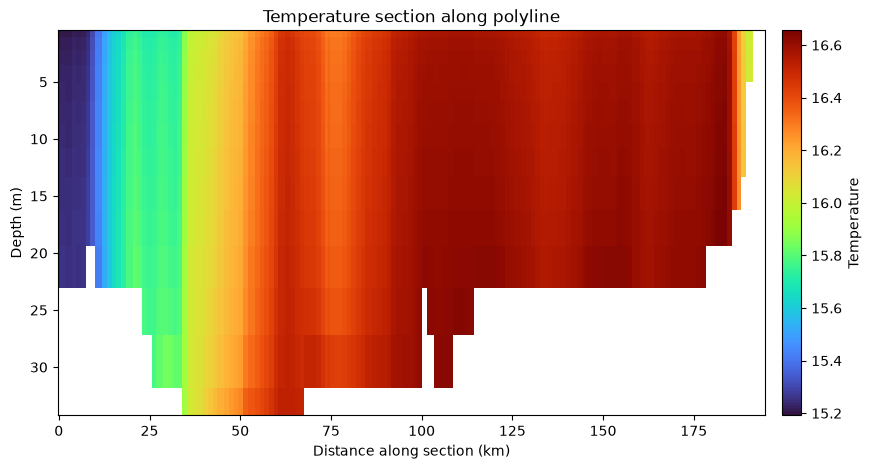

In [12]:
# -------------------------------------------------------------------
# 1) Load GeoJSON from your function
# -------------------------------------------------------------------
geojson = json.loads(get_shapes())

# -------------------------------------------------------------------
# 5) Run it
# -------------------------------------------------------------------
run_geojson_analysis(geojson, ds)